## Video 5: Postprocessing

__Plan__:
1. Make a `sorting_analyzer`
2. Compute lots of extensions: waveforms, spike locations, quality metrics
3. Visualise these, and export a report
   

__Resources__:

[List of postprocessing extensions](https://spikeinterface.readthedocs.io/en/latest/modules/postprocessing.html#available-postprocessing-extensions) \
[Info about quality metrics](https://spikeinterface.readthedocs.io/en/latest/modules/qualitymetrics.html) \
[List of widgets (visualisations)](https://spikeinterface.readthedocs.io/en/latest/modules/widgets.html#available-plotting-functions) 



In [ ]:
import spikeinterface.full as si

In [ ]:
# path_to_np2_recording = "/Volumes/cmvm/sbms/groups/CDBS_SIDB_storage/NolanLab/ActiveProjects/Harry/Cohort11_april2024/vr/M21_D16_2024-05-16_14-40-02_VR1"
# recording = si.read_openephys(path_to_np2_recording)

# assert recording.has_probe() is True

# channel_ids_group_2 = recording.get_channel_ids()[recording.get_property("group")==2]
# recording_group_2 = recording.channel_slice(channel_ids=channel_ids_group_2)

# recording_bandpass = si.bandpass_filter(recording_group_2)
# recording_average = si.common_reference(recording_bandpass, operator="average")

# recording_clip = recording_average.time_slice(
#     start_time=0, end_time=120
# )
# sorting = si.run_sorter(
#     recording = recording_clip,
#     sorter_name = "kilosort4",
# )

project_folder = "/Users/chris/Work/Edinburgh/Spike/Training/L4_sort/"

recording = si.load(project_folder + "three_minute_sample.zarr")
sorting = si.read_kilosort(project_folder + sort_ks4)

In [ ]:
sorting_analyzer_memory = si.create_sorting_analyzer(
    sorting=sorting, 
    recording = recording,
)


In [ ]:
sorting_analyzer = si.load_sorting_analyzer("sorting_analyzer")

In [ ]:
sorting_analyzer_memory.save_as(folder="another_sorting_analyzer", format="binary_folder")

In [ ]:
sorting_analyzer = si.create_sorting_analyzer(
    sorting=sorting, 
    recording = recording_clip,
    format="binary_folder",
    folder="sorting_analyzer"
)

In [ ]:
sorting_analyzer.compute(['random_spikes', 'waveforms', 'principal_components', 'templates'])

In [ ]:
sorting_analyzer.get_extension('templates').get_data()

In [ ]:
%matplotlib widget
si.plot_unit_templates(sorting_analyzer, backend="ipywidgets")

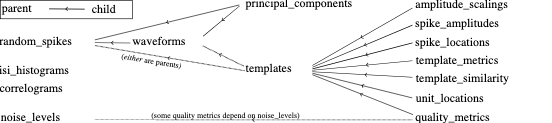

In [ ]:
sorting_analyzer.compute(
    {
        "random_spikes": {"max_spikes_per_unit": 100},
        "waveforms": {},
        "templates": {},
        "spike_locations": {},
        "spike_amplitudes": {},
        "unit_locations": {},
        "correlograms": {},
        "principal_components": {},
        "template_similarity": {},
        "template_metrics": {},
        "noise_levels": {},
        "quality_metrics": {}
    }
)


In [ ]:
sorting_analyzer.get_extension("quality_metrics").get_data()

In [ ]:
si.plot_all_amplitudes_distributions(sorting_analyzer)

In [ ]:
si.plot_unit_summary(sorting_analyzer, unit_id=20)

In [ ]:
si.export_report(sorting_analyzer=sorting_analyzer, output_folder="report")